In [62]:
#Cell 1, Load raw NBA data


import pandas as pd

# Replace this with the actual path to your CSV file
file_path = r"C:\Users\mikey\Desktop\Data Science projects\NBA ALL STAR\2015-2025\nba_2015_2025_cleaned.csv"

# Load the data
nba_df = pd.read_csv(file_path)

# Confirm it worked
print("Shape:", nba_df.shape)
print("Years in dataset:", sorted(nba_df["Year"].unique()))
nba_df.head()




Shape: (3807, 32)
Years in dataset: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Year
0,276.0,A.J. Green,25.0,MIL,SG,73.0,7.0,22.7,2.5,5.8,...,2.1,2.4,1.5,0.5,0.1,0.5,2.2,7.4,NaN,2025
1,218.0,A.J. Lawson,24.0,TOR,SG,26.0,2.0,18.7,3.1,7.3,...,2.5,3.3,1.2,0.5,0.2,0.6,1.7,9.1,NaN,2025
2,217.0,AJ Griffin,19.0,ATL,SF,72.0,12.0,19.5,3.4,7.4,...,1.6,2.1,1.0,0.6,0.2,0.6,1.2,8.9,NaN,2023
3,271.0,AJ Johnson,20.0,WAS,SG,22.0,11.0,27.0,3.4,8.8,...,2.0,2.4,3.1,0.5,0.1,1.4,2.3,9.1,NaN,2025
4,124.0,Aaron Brooks,30.0,CHI,PG,82.0,21.0,23.0,4.2,10.0,...,1.6,2.0,3.2,0.7,0.2,1.9,2.3,11.6,NaN,2015


In [73]:
# Cell 2: Clean data

# 
nba_df = nba_df.sort_values(['Player', 'Year', 'Team'])  # Sort so 'TOT' comes last

# Keep only the last row per player per season — usually the 'TOT' (total stats)
nba_df = nba_df.drop_duplicates(subset=['Player', 'Year'], keep='last')

# Filter out players who averaged fewer than 15 minutes per game
nba_df = nba_df[nba_df['MP'] >= 15]

# Reset index
nba_df = nba_df.reset_index(drop=True)

# Preview cleaned data
print("After filtering by MP >= 15:")
print(nba_df['Year'].value_counts().sort_index())



After filtering by MP >= 15:
Year
2015    336
2016    319
2017    335
2018    350
2019    335
2020    335
2021    365
2022    378
2023    342
2024    338
2025    374
Name: count, dtype: int64


In [74]:
# Cell 4, Label AllStars from 2015 to 2025


# Dictionary of All-Star players by year (sample shown for 2023; you will need to continue filling this)
all_star_dict = {
    2015: ["Stephen Curry", "Kobe Bryant", "Anthony Davis", "Marc Gasol", "Blake Griffin", "James Harden", "Klay Thompson", "Chris Paul", "Russell Westbrook", "LaMarcus Aldridge", "Tim Duncan", "Kevin Durant", "Damian Lillard", "Dirk Nowitzki",
           "John Wall", "Kyle Lowry", "LeBron James", "Pau Gasol", "Carmelo Anthony", "Jimmy Butler", "Chris Bosh", "Paul Millsap", "Kyrie Irving", "Jeff Teague", "Al Horford", "DeMar DeRozan"],
    2016: ["Stephen Curry", "Russell Westbrook", "Kobe Bryant", "Kevin Durant", "Kawhi Leonard", "Chris Paul", "James Harden", "Klay Thompson", "Draymond Green", "Anthony Davis", "DeMarcus Cousins", "LaMarcus Aldridge",
           "LeBron James", "Paul George", "Carmelo Anthony", "Kyle Lowry", "Dwyane Wade", "DeMar DeRozan", "Jimmy Butler", "Isaiah Thomas", "Paul Millsap", "Andre Drummond", "John Wall", "Chris Bosh"],
    2017: ["Kyrie Irving", "DeMar DeRozan", "LeBron James", "Jimmy Butler", "Giannis Antetokounmpo", "Isaiah Thomas", "John Wall", "Kevin Love", "Kyle Lowry", "Paul George", "Kemba Walker", "Paul Millsap",
           "Stephen Curry", "James Harden", "Kevin Durant", "Kawhi Leonard", "Anthony Davis", "Russell Westbrook", "Klay Thompson", "Draymond Green", "DeMarcus Cousins", "Marc Gasol", "DeAndre Jordan", "Gordon Hayward"],
    2018: ["Kyrie Irving", "LeBron James", "Anthony Davis", "DeMarcus Cousins", "Kevin Durant", "LaMarcus Aldridge", "Bradley Beal", "Kevin Love", "Russell Westbrook", "Victor Oladipo", "Kristaps Porziņģis", "John Wall", "Paul George", "Andre Drummond", "Goran Dragić", "Kemba Walker",
           "James Harden", "DeMar DeRozan", "Stephen Curry", "Giannis Antetokounmpo", "Joel Embiid", "Damian Lillard", "Jimmy Butler", "Draymond Green", "Kyle Lowry", "Klay Thompson", "Karl-Anthony Towns", "Al Horford"],
    2019: ["Kemba Walker", "Kyrie Irving", "Kawhi Leonard", "Giannis Antetokounmpo", "Joel Embiid", "Kyle Lowry", "Victor Oladipo", "Khris Middleton", "Bradley Beal", "Ben Simmons", "Blake Griffin", "Nikola Vučević", "Dwyane Wade", "D'Angelo Russell",
       "Stephen Curry", "James Harden", "Kevin Durant", "Paul George", "LeBron James", "Russell Westbrook", "Damian Lillard", "Klay Thompson", "Anthony Davis", "LaMarcus Aldridge", "Nikola Jokić", "Karl-Anthony Towns", "Dirk Nowitzki"],
    2020: ["Kemba Walker", "Trae Young", "Giannis Antetokounmpo", "Pascal Siakam", "Joel Embiid", "Kyle Lowry", "Ben Simmons", "Jimmy Butler", "Khris Middleton", "Bam Adebayo", "Jayson Tatum", "Domantas Sabonis",
       "James Harden", "Luka Dončić", "LeBron James", "Kawhi Leonard", "Anthony Davis", "Chris Paul", "Russell Westbrook", "Damian Lillard", "Donovan Mitchell", "Brandon Ingram", "Nikola Jokić", "Rudy Gobert", "Devin Booker"],
    2021: ["Bradley Beal", "Kyrie Irving", "Giannis Antetokounmpo", "Kevin Durant", "Joel Embiid", "Jaylen Brown", "James Harden", "Zach LaVine", "Ben Simmons", "Julius Randle", "Domantas Sabonis", "Jayson Tatum", "Nikola Vučević",
       "Stephen Curry", "Luka Dončić", "LeBron James", "Kawhi Leonard", "Nikola Jokić", "Devin Booker", "Mike Conley", "Damian Lillard", "Donovan Mitchell", "Chris Paul", "Anthony Davis", "Paul George", "Zion Williamson", "Rudy Gobert"],
    2022: ["Trae Young", "DeMar DeRozan", "Joel Embiid", "Kevin Durant", "Giannis Antetokounmpo", "LaMelo Ball", "Darius Garland", "James Harden", "Zach LaVine", "Fred VanVleet", "Jimmy Butler", "Khris Middleton", "Jayson Tatum", "Jarrett Allen",
       "Stephen Curry", "Ja Morant", "Nikola Jokić", "LeBron James", "Andrew Wiggins", "Devin Booker", "Luka Dončić", "Donovan Mitchell", "Dejounte Murray", "Chris Paul", "Draymond Green", "Rudy Gobert", "Karl-Anthony Towns"],
    2023: ["Kyrie Irving", "Donovan Mitchell", "Giannis Antetokounmpo", "Kevin Durant", "Jayson Tatum", "Jaylen Brown", "DeMar DeRozan", "Tyrese Haliburton", "Jrue Holiday", "Julius Randle", "Bam Adebayo", "Joel Embiid", "Pascal Siakam",
       "Stephen Curry", "Luka Dončić", "Nikola Jokić", "LeBron James", "Zion Williamson", "Shai Gilgeous-Alexander", "Damian Lillard", "Ja Morant", "Paul George", "Jaren Jackson Jr.", "Lauri Markkanen", "Domantas Sabonis", "Anthony Edwards", "De'Aaron Fox"],
    2024: ["Tyrese Haliburton", "Damian Lillard", "Giannis Antetokounmpo", "Jayson Tatum", "Joel Embiid", "Jalen Brunson", "Tyrese Maxey", "Donovan Mitchell", "Trae Young", "Paolo Banchero", "Scottie Barnes", "Jaylen Brown", "Julius Randle", "Bam Adebayo",
       "Luka Dončić", "Shai Gilgeous-Alexander", "Kevin Durant", "LeBron James", "Nikola Jokić", "Devin Booker", "Stephen Curry", "Anthony Edwards", "Paul George", "Kawhi Leonard", "Karl-Anthony Towns", "Anthony Davis"],
    2025: ["Jalen Brunson", "Donovan Mitchell", "Jayson Tatum", "Giannis Antetokounmpo", "Karl-Anthony Towns", "Jaylen Brown", "Cade Cunningham", "Darius Garland", "Tyler Herro", "Damian Lillard", "Evan Mobley", "Pascal Siakam", "Trae Young",
       "Shai Gilgeous-Alexander", "Stephen Curry", "LeBron James", "Kevin Durant", "Nikola Jokić", "Anthony Edwards", "James Harden", "Jaren Jackson Jr.", "Jalen Williams", "Anthony Davis", "Alperen Şengün", "Victor Wembanyama", "Kyrie Irving"]

}

# Function to assign All-Star labels
def label_all_stars(df, all_star_dict):
    df['AllStar'] = df.apply(
        lambda row: 1 if row['Player'] in all_star_dict.get(row['Year'], []) else 0, axis=1
    )
    return df

# Ensure column names are clean (in case of weird spacing or formatting from Basketball-Reference)
df.columns = df.columns.str.strip()

# Apply labeling
df_labeled = label_all_stars(nba_df.copy(), all_star_dict)

# Confirm that data includes all years
print("Years included after labeling:", sorted(df_labeled['Year'].unique()))

# Preview labeled data
df_labeled[["Player", "Year", "AllStar"]].head(10)

Years included after labeling: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,Player,Year,AllStar
0,A.J. Green,2025,0
1,A.J. Lawson,2025,0
2,AJ Griffin,2023,0
3,AJ Johnson,2025,0
4,Aaron Brooks,2015,0
5,Aaron Brooks,2016,0
6,Aaron Gordon,2015,0
7,Aaron Gordon,2016,0
8,Aaron Gordon,2017,0
9,Aaron Gordon,2018,0


In [76]:
# Cell 5 – Use only CustomScore for model input


from sklearn.model_selection import train_test_split

# Make sure we're not using rows with missing critical values
df_labeled = df_labeled.dropna(subset=['PTS', 'AST', 'TRB', 'STL', 'BLK', 'MP', 'AllStar'])

# Ensure 'CustomScore' exists or recalculate
df_labeled['CustomScore'] = (
    df_labeled['PTS'] * 1.0 +
    df_labeled['AST'] * 1.5 +
    df_labeled['TRB'] * 1.2 +
    df_labeled['STL'] * 1.2 +
    df_labeled['BLK'] * 1.2 +
    df_labeled['MP'] * 0.1
)

# Confirm score distribution (optional but helpful for debugging)
print(df_labeled.groupby('Year')['CustomScore'].mean().tail())

# Select features and target
X = df_labeled[['CustomScore']]
y = df_labeled['AllStar']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

print("CustomScore counts by year (train set):")
print(X_train.join(y_train).groupby(df_labeled.loc[X_train.index, "Year"])["CustomScore"].mean())


Year
2021    25.207014
2022    24.989656
2023    26.135848
2024    26.121982
2025    25.747032
Name: CustomScore, dtype: float64
Training samples: 3045
Test samples: 762
CustomScore counts by year (train set):
Year
2015    23.096023
2016    23.698333
2017    23.933298
2018    24.169427
2019    25.175199
2020    25.968927
2021    25.306701
2022    25.140133
2023    25.904481
2024    25.888694
2025    26.043528
Name: CustomScore, dtype: float64


In [77]:
# Cell 6: Training cell


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Ensure CustomScore exists
df_labeled['CustomScore'] = (
    df_labeled['PTS'] * 1.0 +
    df_labeled['AST'] * 1.5 +
    df_labeled['TRB'] * 1.2 +
    df_labeled['STL'] * 1.2 +
    df_labeled['BLK'] * 1.2 +
    df_labeled['MP'] * 0.1
)

# Step 2: Drop rows with missing values in CustomScore or AllStar
df_labeled = df_labeled.dropna(subset=['CustomScore', 'AllStar'])

# Step 3: Select only CustomScore as input feature
X = df_labeled[['CustomScore']]
y = df_labeled['AllStar']

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 6: Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))




Accuracy: 0.9606299212598425
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       705
           1       0.79      0.65      0.71        57

    accuracy                           0.96       762
   macro avg       0.88      0.82      0.85       762
weighted avg       0.96      0.96      0.96       762



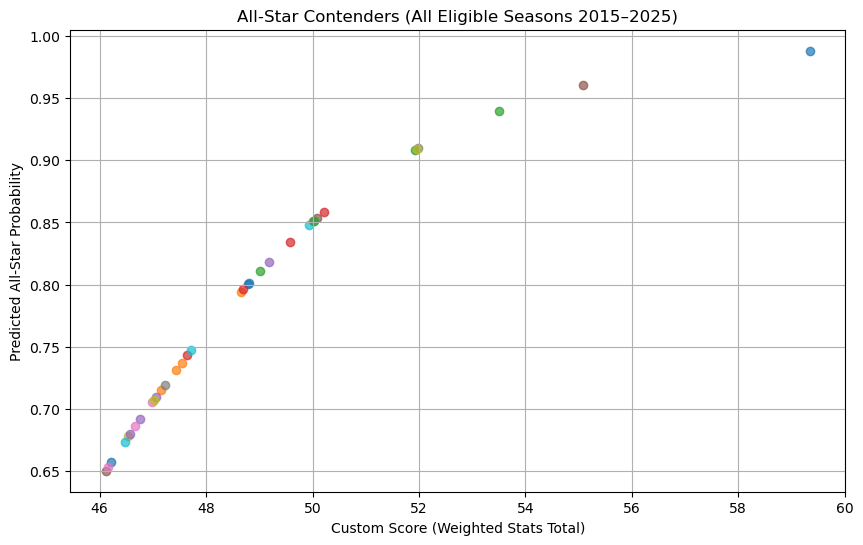

,Player,Year,PTS,AST,TRB,STL,BLK,MP,CustomScore,AllStar_Prob
3192,Russell Westbrook,2021,22.2,11.7,11.5,1.4,0.4,36.4,59.35,0.988191
2423,Luka Dončić,2025,28.2,7.5,8.1,1.6,0.4,35.1,55.08,0.960805
977,Domantas Sabonis,2024,19.4,8.2,13.7,0.9,0.6,35.7,53.51,0.939789
812,DeMarcus Cousins,2015,24.1,3.6,12.7,1.5,1.7,34.1,51.99,0.909763
2036,Karl-Anthony Towns,2020,26.5,4.4,10.8,0.9,1.2,33.9,51.97,0.909290
174,Anthony Davis,2023,25.9,2.6,12.5,1.1,2.0,34.0,51.92,0.908097
324,Bradley Beal,2020,30.5,6.1,4.2,1.2,0.4,36.0,50.21,0.858019
1593,James Harden,2023,21.0,10.7,6.1,1.2,0.5,36.8,50.09,0.853763
3540,Trae Young,2023,26.2,10.2,3.0,1.1,0.1,34.8,50.02,0.851232
2033,Karl-Anthony Towns,2017,25.1,2.7,12.3,0.7,1.3,37.0,50.01,0.850868


In [81]:
# Contend

# Ensure custom score is calculated
df_labeled['CustomScore'] = (
    df_labeled['PTS'] * 1.0 +
    df_labeled['AST'] * 1.5 +
    df_labeled['TRB'] * 1.2 +
    df_labeled['STL'] * 1.2 +
    df_labeled['BLK'] * 1.2 +
    df_labeled['MP'] * 0.1
)

# Predict All-Star probabilities using model trained on CustomScore only
X_all = df_labeled[['CustomScore']]
df_labeled['AllStar_Prob'] = model.predict_proba(X_all)[:, 1]

# Filter: keep all non-All-Stars with predicted All-Star probability > 0.2
contenders = df_labeled[(df_labeled['AllStar'] == 0) & (df_labeled['AllStar_Prob'] > 0.65)]

# Group by Player + Year to ensure each season is unique
contenders = contenders.drop_duplicates(subset=['Player', 'Year'])

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for _, row in contenders.iterrows():
    plt.scatter(row['CustomScore'], row['AllStar_Prob'], label=f"{row['Player']} ({row['Year']})", alpha=0.7)

plt.xlabel('Custom Score (Weighted Stats Total)')
plt.ylabel('Predicted All-Star Probability')
plt.title('All-Star Contenders (All Eligible Seasons 2015–2025)')
plt.grid(True)
plt.show()

# Show top 25 unique player-seasons by CustomScore
contenders[['Player', 'Year', 'PTS', 'AST', 'TRB', 'STL', 'BLK', 'MP', 'CustomScore', 'AllStar_Prob']] \
    .sort_values(by='CustomScore', ascending=False).head(100)

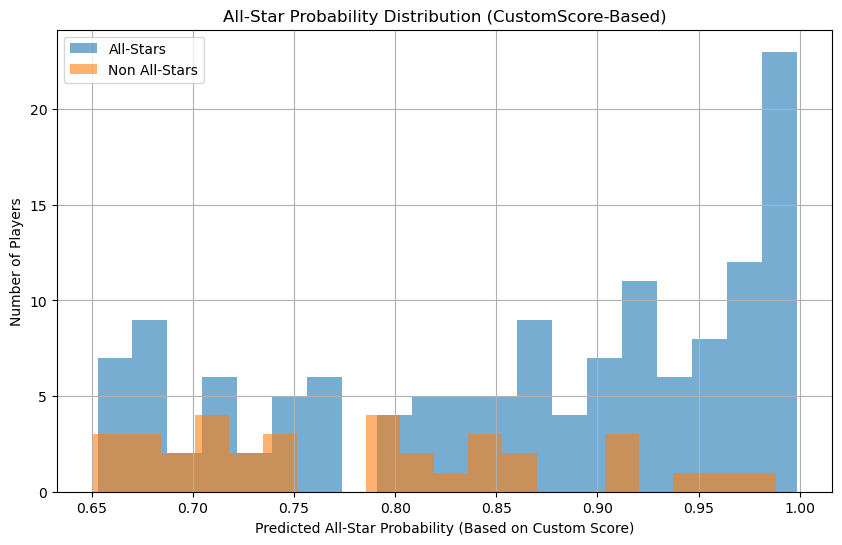

In [83]:
# All-Star Probability Distribution (Only players with probability > 0.2 using CustomScore)

import matplotlib.pyplot as plt

# Ensure probability column is using CustomScore-based model
df_labeled['AllStar_Prob'] = model.predict_proba(df_labeled[['CustomScore']])[:, 1]

# Filter players with predicted All-Star probability ≥ 0.65
high_prob = df_labeled[df_labeled['AllStar_Prob'] >= 0.65]

# Separate into actual All-Stars and Non-All-Stars
allstars = high_prob[high_prob['AllStar'] == 1]
non_allstars = high_prob[high_prob['AllStar'] == 0]

# Plot the histograms
plt.figure(figsize=(10, 6))
plt.hist(allstars['AllStar_Prob'], bins=20, alpha=0.6, label='All-Stars')
plt.hist(non_allstars['AllStar_Prob'], bins=20, alpha=0.6, label='Non All-Stars')
plt.xlabel('Predicted All-Star Probability (Based on Custom Score)')
plt.ylabel('Number of Players')
plt.title('All-Star Probability Distribution (CustomScore-Based)')
plt.legend()
plt.grid(True)
plt.show()



In [94]:
# Show snubbed players 

# Predict All-Star probability using only CustomScore
df_labeled['AllStar_Prob'] = model.predict_proba(df_labeled[['CustomScore']])[:, 1]

# Keep only players who were NOT All-Stars
potential_snubs = df_labeled[df_labeled['AllStar'] == 0]

# Filter: only players with predicted All-Star probability ≥ 0.2
snubs = potential_snubs[potential_snubs['AllStar_Prob'] >= 0.65]

# Show top 15 snubbed players by All-Star probability
snubs[['Player', 'Year', 'PTS', 'AST', 'TRB', 'MP', 'CustomScore', 'AllStar_Prob']] \
    .sort_values(by='AllStar_Prob', ascending=False).head(50)


,Player,Year,PTS,AST,TRB,MP,CustomScore,AllStar_Prob
3192,Russell Westbrook,2021,22.2,11.7,11.5,36.4,59.35,0.988191
2423,Luka Dončić,2025,28.2,7.5,8.1,35.1,55.08,0.960805
977,Domantas Sabonis,2024,19.4,8.2,13.7,35.7,53.51,0.939789
812,DeMarcus Cousins,2015,24.1,3.6,12.7,34.1,51.99,0.909763
2036,Karl-Anthony Towns,2020,26.5,4.4,10.8,33.9,51.97,0.909290
174,Anthony Davis,2023,25.9,2.6,12.5,34.0,51.92,0.908097
324,Bradley Beal,2020,30.5,6.1,4.2,36.0,50.21,0.858019
1593,James Harden,2023,21.0,10.7,6.1,36.8,50.09,0.853763
3540,Trae Young,2023,26.2,10.2,3.0,34.8,50.02,0.851232
2033,Karl-Anthony Towns,2017,25.1,2.7,12.3,37.0,50.01,0.850868


In [93]:
# Test Player 


# Define the custom player's stats
custom_stats = {
    'PTS': 15.5,
    'AST': 11.5,
    'TRB': 3.3,
    'STL': 1.0,
    'BLK': 0.1,
    'MP': 34.3
}

# Calculate custom score using the same weights
custom_score = (
    custom_stats['PTS'] * 1.0 +
    custom_stats['AST'] * 1.5 +
    custom_stats['TRB'] * 1.2 +
    custom_stats['STL'] * 1.2 +
    custom_stats['BLK'] * 1.2 +
    custom_stats['MP'] * 0.1
)

# Create DataFrame for prediction
custom_input = pd.DataFrame({'CustomScore': [custom_score]})

# Predict All-Star status based on custom score
prediction = model.predict(custom_input)
probability = model.predict_proba(custom_input)[0, 1]

# Show result
print(f"Custom Score: {custom_score:.2f}")
print("All-Star Prediction:", "⭐ YES!" if prediction[0] == 1 else "❌ Nope.")
print(f"Predicted Probability: {probability:.2%}")


Custom Score: 41.46
All-Star Prediction: ❌ Nope.
Predicted Probability: 32.81%
